# JetClassLite attention γ (star-$R$)

Estimate CAPEN / CAPEN-Llama pre-softmax temperatures $\gamma_{rs}$ as **mean nonempty row degrees** of supports $M_{11}/M_{12}/M_{21}/M_{22}$ on the JetClassLite star cache.

Run with the `mamba-env` kernel from the repo (or `notebooks/`). First code cell forces CPU so `import torch` does not hang probing GPUs on a login node.

In [2]:
from __future__ import annotations

import os

# Login nodes: prevent torch from probing CUDA (can hang the kernel).
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "")
os.environ.setdefault("OMP_NUM_THREADS", "4")

import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

print("imports (non-torch) ok", flush=True)

import torch

print(f"torch {torch.__version__} cuda_available={torch.cuda.is_available()}", flush=True)

REPO_CANDIDATES = [
    Path("/home/jdezoort/coupled-particle-edge-networks"),
    Path.cwd().resolve(),
    Path.cwd().resolve().parent,
]
REPO = next(p for p in REPO_CANDIDATES if (p / "src" / "cpen").is_dir())
for p in (REPO, REPO / "src"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from cpen.utils.attention_temperature import (
    AttentionGammas,
    _build_attention_supports,
    _dense_incidence_from_coo_payload,
    support_row_degrees,
)
from cpen.utils.jetclass_star_cache import jetclass_star_cache_available
from cpen.utils.star_graph_cache import (
    load_star_graph_cache_mmap,
    processed_star_split_dir,
)

DATA_ROOT = Path("/scratch/gpfs/BHANIN/jdezoort/datasets/jetclass")
STAR_RADIUS = 0.15
NUM_PARTICLES = 128
SPLIT = "train"
N_JETS = 512
BATCH_SIZE = 32  # smaller batches → visible progress, less RAM spikes
SEED = 42
ALL_TO_ALL_11 = True  # CAPEN-Llama jets

print(f"REPO={REPO}", flush=True)
print(f"DATA_ROOT exists={DATA_ROOT.is_dir()}", flush=True)

imports (non-torch) ok
torch 2.4.0+cu121 cuda_available=True
REPO=/home/jdezoort/coupled-particle-edge-networks
DATA_ROOT exists=True


In [3]:
assert jetclass_star_cache_available(
    cache_root=str(DATA_ROOT),
    split=SPLIT,
    radius=STAR_RADIUS,
    num_particles=NUM_PARTICLES,
    max_jets=None,
    seed=SEED,
), f"Missing JetClass star cache under {DATA_ROOT}"

cache_dir = processed_star_split_dir(
    DATA_ROOT, radius=STAR_RADIUS, num_particles=NUM_PARTICLES
)
meta = json.loads((cache_dir / "meta.json").read_text())
t0 = time.time()
payload = load_star_graph_cache_mmap(cache_dir / f"{SPLIT}.pt")
print(f"mmap open in {time.time() - t0:.2f}s", flush=True)

n_total = int(payload["mask"].size(0))
rng = np.random.default_rng(SEED)
pick = rng.choice(n_total, size=min(N_JETS, n_total), replace=False)

print(f"cache: {cache_dir}", flush=True)
print(
    f"meta: dataset={meta.get('dataset')} norm={meta.get('particle_normalization')} "
    f"edge={meta.get('edge_feature')} R={meta.get('radius')} n={meta.get('num_particles')}",
    flush=True,
)
print(f"sampling {len(pick):,} / {n_total:,} {SPLIT} jets", flush=True)

mmap open in 0.08s
cache: /scratch/gpfs/BHANIN/jdezoort/datasets/jetclass/processed/star-r0p1500/n128
meta: dataset=jetclass-lite norm=part-full-l2-sqrt-dim edge=logdot_dp_l2-sqrt-dim R=0.15 n=128
sampling 512 / 5,000,000 train jets


In [4]:
degree_lists: dict[str, list[np.ndarray]] = {k: [] for k in ("11", "12", "21", "22")}
has_dense = "incidence" in payload
n_batches = (len(pick) + BATCH_SIZE - 1) // BATCH_SIZE
t0 = time.time()

for b, start in enumerate(range(0, len(pick), BATCH_SIZE)):
    idx = pick[start : start + BATCH_SIZE]
    idx_t = torch.as_tensor(idx, dtype=torch.long)
    mask = payload["mask"][idx_t].bool()
    if has_dense:
        s_bool = payload["incidence"][idx_t].bool()
    else:
        s_bool = _dense_incidence_from_coo_payload(payload, idx_t)

    m_11, m_21, m_12, m_22 = _build_attention_supports(
        s_bool,
        mask,
        all_to_all_particle_attention=ALL_TO_ALL_11,
    )
    for key, support in (("11", m_11), ("12", m_12), ("21", m_21), ("22", m_22)):
        deg = support_row_degrees(support).reshape(-1).detach().cpu().numpy()
        degree_lists[key].append(deg[deg >= 1].astype(np.float64))

    # Drop batch tensors so the kernel does not retain a huge live graph.
    del mask, s_bool, m_11, m_21, m_12, m_22

    if (b + 1) == 1 or (b + 1) % 4 == 0 or (b + 1) == n_batches:
        print(
            f"  batch {b + 1}/{n_batches}  elapsed {time.time() - t0:.1f}s",
            flush=True,
        )

summaries: dict[str, dict] = {}
means: dict[str, float] = {}
for key, chunks in degree_lists.items():
    vals = np.concatenate(chunks) if chunks else np.array([], dtype=np.float64)
    if vals.size == 0:
        summaries[key] = {
            "n_rows": 0,
            "mean": 1.0,
            "std": 0.0,
            "min": 1.0,
            "max": 1.0,
            "median": 1.0,
            "degrees": vals,
        }
        means[key] = 1.0
    else:
        summaries[key] = {
            "n_rows": int(vals.size),
            "mean": float(vals.mean()),
            "std": float(vals.std()),
            "min": float(vals.min()),
            "max": float(vals.max()),
            "median": float(np.median(vals)),
            "degrees": vals,
        }
        means[key] = float(vals.mean())

gammas = AttentionGammas(
    gamma_11=means["11"],
    gamma_12=means["12"],
    gamma_21=means["21"],
    gamma_22=means["22"],
)

print("\nRecommended --attention-normalization gamma values:", flush=True)
print(
    f"  --gamma-11 {gammas.gamma_11:.4g} "
    f"--gamma-12 {gammas.gamma_12:.4g} "
    f"--gamma-21 {gammas.gamma_21:.4g} "
    f"--gamma-22 {gammas.gamma_22:.4g}",
    flush=True,
)
print(flush=True)
for rel, s in summaries.items():
    print(
        f"M_{rel}: n_rows={s['n_rows']:,}  "
        f"mean={s['mean']:.3f}  median={s['median']:.3f}  "
        f"std={s['std']:.3f}  min={s['min']:.0f}  max={s['max']:.0f}",
        flush=True,
    )

  batch 1/16  elapsed 5.8s
  batch 4/16  elapsed 6.0s
  batch 8/16  elapsed 6.2s
  batch 12/16  elapsed 6.4s
  batch 16/16  elapsed 6.7s

Recommended --attention-normalization gamma values:
  --gamma-11 46.24 --gamma-12 14.69 --gamma-21 14.69 --gamma-22 7.515

M_11: n_rows=20,435  mean=46.235  median=45.000  std=16.527  min=11  max=108
M_12: n_rows=20,435  mean=14.691  median=14.000  std=9.253  min=1  max=57
M_21: n_rows=20,435  mean=14.691  median=14.000  std=9.253  min=1  max=57
M_22: n_rows=65,536  mean=7.515  median=1.000  std=12.189  min=1  max=66


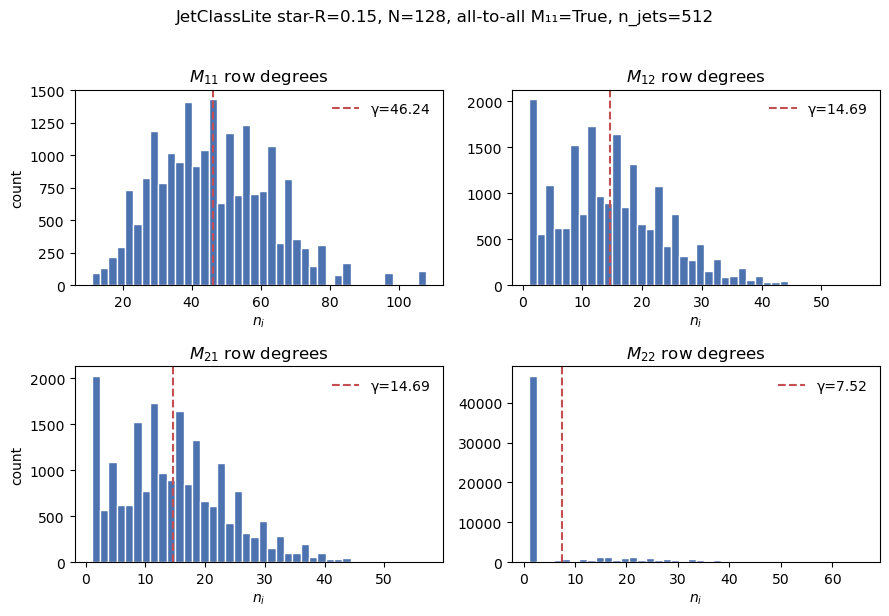

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(9, 6), sharey=False)
for ax, rel in zip(axes.ravel(), ("11", "12", "21", "22")):
    vals = summaries[rel]["degrees"]
    ax.hist(
        vals,
        bins=min(40, max(5, int(np.sqrt(max(len(vals), 1))))),
        color="#4C72B0",
        edgecolor="white",
    )
    ax.axvline(
        summaries[rel]["mean"],
        color="#C44E52",
        ls="--",
        lw=1.5,
        label=f"γ={summaries[rel]['mean']:.2f}",
    )
    ax.set_title(f"$M_{{{rel}}}$ row degrees")
    ax.set_xlabel("$n_i$")
    ax.legend(frameon=False)
axes[0, 0].set_ylabel("count")
axes[1, 0].set_ylabel("count")
fig.suptitle(
    f"JetClassLite star-R={STAR_RADIUS:g}, N={NUM_PARTICLES}, "
    f"all-to-all M₁₁={ALL_TO_ALL_11}, n_jets={len(pick)}",
    y=1.02,
)
fig.tight_layout()
plt.show()

## Paste into training

```bash
python scans/testing/test_cpen_jetclass.py \
  --model capen-llama --star-radius 0.15 \
  --attention-normalization gamma \
  --gamma-11 … --gamma-12 … --gamma-21 … --gamma-22 …
```

With all-to-all particles, $\gamma_{11} \approx \langle N_{\mathrm{valid}}\rangle$.